## Define model

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from scipy.signal import square
from math import floor
from numba import njit


# Define the model WITH delays for lysis and for pili expression after plasmid acquisition
def model_w_delays(t, y, alpha, gamma, delta, K, cost, pl, T_pili, N):
    y = y.reshape(3+N) #for some reason without this y = [y0,y1,...,yn] becomes y = [[y0],[y1],...,[yn]]
    B0 = y[0]
    BP = y[1]
    Bc = y[2]
    i_scalars = slice(0,3)
    i_BPnp = slice(3,3+N)
    BPnp = y[3:3+N].reshape(N)
  
    C = 1 - (B0 + BP + Bc)/K
    dB0dt =  alpha*C*(B0 + pl*(1+cost)*BP) - gamma*B0*BP - delta*B0 
    dBPdt = alpha*(1 + cost)*C*(1 - pl)*BP + (N/T_pili)*BPnp[-1]  - delta*BP
    dBcdt = alpha*C*Bc- delta*Bc
    
    #calculate vector-valued terms pili expression intermediate states
    dBPnpdt = np.zeros(len(BPnp))
    dBPnpdt[0] = gamma*BP*B0 -(N/T_pili)*BPnp[0] - delta*BPnp[0] 
    for i in range(1, len(BPnp)):
        dBPnpdt[i] = (N/T_pili)*(BPnp[i-1] - BPnp[i]) - delta*BPnp[i]
    
    result = np.empty_like(y)
    scalar_vars = [dB0dt, dBPdt, dBcdt]
    result[i_scalars] = scalar_vars
    result[i_BPnp] = dBPnpdt
    return result


## Define parameters

In [2]:
#define parameters
alpha = 1.0        # Growth rate of the bacteria w/o the plasmid
gamma = 1*10**(-8)     # Conjugation rate
delta = 0.10     #Death rate of bacteria
K = 10**8  #carrying capacity
cost = -0.5 #growth cost of plasmid
pl = 0.001     # Probability of losing the plasmid




#Simulation parameters
tf = 10**4 #Time to be simulated
dt_save = 0.5 #time span between saved data points
tEq = 1000 #time to reach steady state before introducing competitor

# Initial condition
B00 = K
BP0 =  K
P0 = 0 #No phage in this simulation
Bc0 = 0 #add competitor after equilibrium is reached

#delay params
T_pili = 0.5
N = 5

params = [alpha, gamma, delta, K, cost, pl, T_pili, N]




## Simulate competitor invasion

In [5]:
#delay params
T_pili = 0.5
N = 5

params = [alpha, gamma, delta, K, cost, pl, T_pili, N]


#Simulation parameters
tf = 10**4 #Time to be simulated
dt_save = 0.5 #time span between saved data points


# Initial condition
B00 = K
BP0 =  K
Bc0 = 0 #add competitor after equilibrium is reached
BPnp0 = np.zeros(N)
scalar_vars0 = [B00, BP0, Bc0]
y0 = np.empty(3+N)
i_scalars = slice(0,3)
i_BPnp = slice(3, 3+ N)
y0[i_scalars] = scalar_vars0
y0[i_BPnp] = BPnp0


#run simulation without competitor until equilibrium
###################################################

t0 = 0
solEq = solve_ivp(
        model_w_delays,
        [t0, tEq],
        y0,
        t_eval=np.arange(t0, tEq, dt_save),
        args = params,
        dense_output=False,
        vectorized = True,
        method='LSODA', 
        max_step=1.0 
    )


#Add competitor
#####################################
yEq = solEq.y[:, -1].copy()
yEq[2] = 10
y0 = yEq
t0 = 0


#Define exctinction events (params are needed because solve_ivp always calls the event functions using them)
##################################################################################
def Bp_extinction_event(t, y, alpha, gamma, delta, K, cost, pl, T_pili, N):
    return y[1] - 1.0
Bp_extinction_event.terminal = True
Bp_extinction_event.direction = -1

def Bc_extinction_event(t, y, alpha, gamma, delta, K, cost, pl, T_pili, N):
    return y[2] - 1.0
Bc_extinction_event.terminal = True
Bc_extinction_event.direction = -1


extinction_events = [Bp_extinction_event, Bc_extinction_event]


#Run simulation loop that halts when extinction events are triggered and restarts with extinct populations set to zero
#####################################
t_all = []
y_all = []
while t0 < tf:
    sol = solve_ivp(
        model_w_delays,
        [t0, tf],
        y0,
        events=extinction_events,
        t_eval=np.arange(t0, tf, dt_save),
        args = params,
        dense_output=False,
        method='LSODA', 
        max_step=10.0
    )


    # Store results
    t_all.extend(sol.t)
    y_all.extend(sol.y.T)
    # Check which event triggered
    triggered = [len(ev) > 0 for ev in sol.t_events]
    y0 = sol.y[:, -1].copy()


    if triggered[0]:  #plasmid extinction
        y0[1] = 0.0
    if triggered[1]:  #competitor extinction
        y0[2] = 0.0

    if not any(triggered):
        break  # no events, done
    else:
        t0 = sol.t[-1]




#store simulation output data
data2 = np.array(y_all)
t2 = t_all.copy()



## Create plot

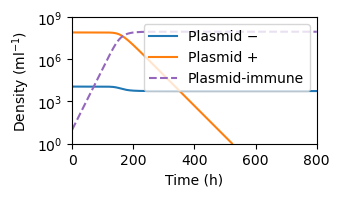

In [6]:
import matplotlib.pyplot as plt

datasets = [data2]
times = [t2]
labels = ['Plasmid −', 'Plasmid +', 'Plasmid-immune']
styles = ["-", "-", "--"]
colors = ["C0","C1", "C4"]
# Create plot
fig, ax = plt.subplots(nrows=1, sharex=True, figsize=(3.5, 2))
for data, t in zip(datasets, times):
    for y, style, label, color in zip(data.T, styles, labels, colors):
        ax.plot(t, y, linestyle=style, label=label, color=color) 
    ax.margins(x=0)  # no extra padding on the x-axis
    ax.set_ylim(10**0, 10**9)
    ax.set_xlim(0, 0.8*10**3)
    ax.set_yscale('log')
    #ax.set_xscale('log')
    ax.set_ylabel('Density (ml$^{-1}$)')
    ax.grid(False)

# Only the bottom plot gets the x-axis label
ax.set_xlabel('Time (h)')

# Only the top plot gets the legend
ax.legend()

plt.tight_layout()
plt.savefig('Figure_1C.svg', format = 'svg')


## Calculate persistence time colormap (may take several minutes)

In [7]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from IPython.display import clear_output



# ---- parameter grids ----
N_plot = 100
gamma_vals = np.logspace(-10.2, -7.7, N_plot)
pl_vals = np.logspace(-3.5, -0.05, N_plot)

# storage for plasmid extinction times
t_extinct = np.full((len(gamma_vals), len(pl_vals)), np.nan)

p_eq = np.full((len(gamma_vals), len(pl_vals)), np.nan)

# ---- plasmid extinction event
def make_event(idx):
    def extinction_event(t, y, *args):
        return y[idx] -1.0
    extinction_event.terminal = True      # stop at first crossing
    extinction_event.direction = -1       # only detect downward crossing
    return extinction_event

pls_ext_event = make_event(idx=1)   # track y[1]

# ---- loop over parameter grid ----
for i, gamma in enumerate(gamma_vals):
    for j, pl in enumerate(pl_vals):
        
        #progress tracker
        clear_output(wait=True)
        print(f"Progress: {i/N_plot*100 + j/N_plot**2*100}%")

        #place gamma and pl values into parameters
        params = [alpha, gamma, delta, K, cost, pl, T_pili, N]
        
        
        #initial state
        i_scalars = slice(0,3)
        i_BPnp = slice(3, 3+N)
        y0 = np.zeros(3+N)
        y0scalars = np.array([B00, BP0, Bc0])
        y0[i_scalars] = y0scalars
        y0[i_BPnp] = np.zeros(N)
        t0 = 0

        

        #check if plasmid can survive even without competitor (Eq 4, Lopez et al. 2021, note the opposite sign convention for cost!)
        B0eq = K*(1-delta/alpha)

        if gamma <= delta*(-cost + (1 + cost)*pl)/B0eq: #If true, plasmid cannot survive
            p_eq[i,j] = 0
            t_extinct[i, j] = np.nan
            
        else:
            #Run until equilibrium without competitor
            solEq = solve_ivp(
            model_w_delays,
            [t0, tEq],
            y0,
            t_eval=np.arange(t0, tEq),
            args = params,
            dense_output=False,
            vectorized = True,
            method='LSODA', 
            max_step=1.0 
            )

            #save plasmid fraction data
            yEq = solEq.y[:, -1].copy()
            p_eq[i,j] = yEq[1]/(yEq[0] + yEq[1])
            
            #Add competitor
            #####################################
            y0 = yEq
            y0[2] = 10
            t0 = 0
            #Run simulation loop that halts when extinction events are triggered and restarts with extinct populations set to zero
            #####################################
            t_all = []
            y_all = []
            tf = 10**5 #maximum simulation time
            sol = solve_ivp(
            model_w_delays,
            [t0, tf],
            y0,
            events=[pls_ext_event],
            t_eval=np.arange(t0, tf),
            args = params,
            dense_output=False,
            method='LSODA', 
            max_step=1.0
            )

            #print(sol.y[:,-1])
            # add time at plasmid extinction to data array
            if sol.t_events[0].size > 0:
                t_extinct[i, j] = sol.t_events[0][0]

            else:
                t_extinct[i, j] = tf  # this should not happen unless the timescale for plasmid extinction is longer than tf (which will just be >max on the color map anyways)
                print(f"time = >{tf} hours")

print("Done!")

Progress: 99.99%
Done!


## Plot persistence time colormap

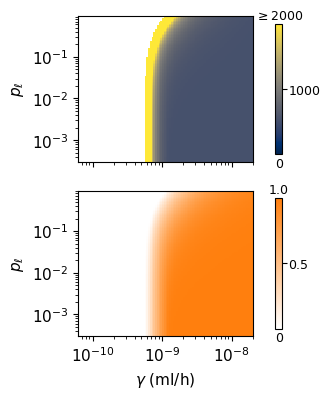

In [8]:
from matplotlib.colors import LinearSegmentedColormap


P1, P2 = np.meshgrid(gamma_vals, pl_vals, indexing='ij')


fig, axes = plt.subplots(
    2, 1,
    figsize=(3, 4.15),
    sharex=True,
    constrained_layout=False
)
# ---------------- Top panel ----------------
ax = axes[0]

im1 = ax.pcolormesh(
    P1, P2, t_extinct,
    shading='auto',
    vmin=0,
    vmax=2000,
    rasterized=True,
    cmap = 'cividis'
)

ax.set_xscale('log')
ax.tick_params(labelbottom=False)
ax.set_yscale('log')
ax.set_ylabel(r'$p_\ell$', fontsize=11)
ax.tick_params(axis='both', labelsize=11)

cbar1 = plt.colorbar(im1, ax=axes[0], shrink=0.9, pad=0.095)

# only interior ticks
cbar1.set_ticks([1000])
cbar1.ax.tick_params(labelsize=9, pad=1)

# manual min/max labels
cbar1.ax.text(0.5, 1.01, r'$\geq 2000$', ha='center', va='bottom',
              transform=cbar1.ax.transAxes, fontsize=9)
cbar1.ax.text(0.5, -0.02, '0', ha='center', va='top',
              transform=cbar1.ax.transAxes, fontsize=9)

# ---------------- Bottom panel ----------------
ax = axes[1]

colors = ["white", "C1"]
cmap1 = LinearSegmentedColormap.from_list("mycmap", colors)

im2 = ax.pcolormesh(
    P1, P2, p_eq,
    shading='auto',
    cmap=cmap1,
    vmin=0,
    vmax=1.0,
    rasterized=True
)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\gamma$ (ml/h)', fontsize=11)
ax.set_ylabel(r'$p_\ell$', fontsize=11)
ax.tick_params(axis='both', labelsize=11)


cbar2 = plt.colorbar(im2, ax=axes[1], shrink=0.9, pad=0.095)

cbar2.set_ticks([0.5])
cbar2.ax.tick_params(labelsize=9, pad=1)

cbar2.ax.text(0.5, 1.01, '1.0', ha='center', va='bottom',
              transform=cbar2.ax.transAxes, fontsize=9)
cbar2.ax.text(0.5, -0.02, '0', ha='center', va='top',
              transform=cbar2.ax.transAxes, fontsize=9)

fig.savefig("Figure_1D.svg", dpi=300, bbox_inches="tight")
plt.show()